# FastF1 2025 — Local Preprocessing & EDA

Notebook ini **local-only**, untuk dijalankan melalui Jupyter Notebook / JupyterLab / VS Code pada komputer lokal.

Tidak menggunakan:
- Google Colab
- Google Drive
- bundle upload
- `/content`

## Struktur project

```text
F1_Tableau_Project/
├── data/
│   └── fastf1_cache/
├── notebook/
│   ├── 01_kaggle_preprocessing_eda_local.ipynb
│   └── 02_fastf1_preprocessing_eda_local.ipynb
└── outputs/
```

## Scope

Musim: **2025**

Session: **Race**

Circuit:
- Monaco
- Great Britain
- Italy
- Belgium
- Austria

Untuk setiap race:
- pilih podium P1–P3,
- ambil fastest valid lap,
- ambil car telemetry,
- ambil positional telemetry,
- merge menggunakan `Time`,
- lakukan EDA,
- ekspor CSV siap Tableau.

## 1. Install Dependencies

FastF1 dipin ke **3.8.3** agar environment reproducible.

In [1]:
%pip install -q "fastf1==3.8.3" pandas numpy matplotlib pyarrow


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Setup Project Directory

In [2]:
from pathlib import Path
import re
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

import fastf1
from fastf1.exceptions import DataNotLoadedError

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)

cwd = Path.cwd().resolve()

if cwd.name.lower() == "notebook":
    PROJECT_DIR = cwd.parent
else:
    PROJECT_DIR = cwd

DATA_DIR = PROJECT_DIR / "data"
CACHE_DIR = DATA_DIR / "fastf1_cache"
NOTEBOOK_DIR = PROJECT_DIR / "notebook"
OUTPUT_DIR = PROJECT_DIR / "outputs"

for folder in [
    DATA_DIR,
    CACHE_DIR,
    NOTEBOOK_DIR,
    OUTPUT_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

SEASON = 2025
SESSION_CODE = "R"

fastf1.Cache.enable_cache(str(CACHE_DIR))

print("FastF1 version :", fastf1.__version__)
print("Project        :", PROJECT_DIR)
print("Cache          :", CACHE_DIR)
print("Outputs        :", OUTPUT_DIR)

FastF1 version : 3.8.3
Project        : /home/user/projects/avd-uts
Cache          : /home/user/projects/avd-uts/data/fastf1_cache
Outputs        : /home/user/projects/avd-uts/outputs


## 3. Load 2025 Event Schedule

Nama event tidak diasumsikan secara manual. Notebook membaca schedule FastF1 terlebih dahulu.

In [3]:
schedule = fastf1.get_event_schedule(
    SEASON,
    include_testing=False
)

show_columns = [
    col
    for col in [
        "RoundNumber",
        "Country",
        "Location",
        "EventName",
        "EventDate"
    ]
    if col in schedule.columns
]

display(schedule[show_columns])

,RoundNumber,Country,Location,EventName,EventDate
1,1,Australia,Melbourne,Australian Grand Prix,2025-03-16
2,2,China,Shanghai,Chinese Grand Prix,2025-03-23
3,3,Japan,Suzuka,Japanese Grand Prix,2025-04-06
4,4,Bahrain,Sakhir,Bahrain Grand Prix,2025-04-13
5,5,Saudi Arabia,Jeddah,Saudi Arabian Grand Prix,2025-04-20
6,6,United States,Miami Gardens,Miami Grand Prix,2025-05-04
7,7,Italy,Imola,Emilia Romagna Grand Prix,2025-05-18
8,8,Monaco,Monaco,Monaco Grand Prix,2025-05-25
9,9,Spain,Barcelona,Spanish Grand Prix,2025-06-01
10,10,Canada,Montréal,Canadian Grand Prix,2025-06-15


## 4. Resolve Target Events

In [4]:
TARGET_EVENTS = {
    "Monaco": ["Monaco"],
    "Great Britain": ["British", "Great Britain"],
    "Italy": ["Italian", "Italy"],
    "Belgium": ["Belgian", "Belgium"],
    "Austria": ["Austrian", "Austria"],
}

def normalize_text(value):
    return re.sub(
        r"[^a-z0-9]+",
        " ",
        str(value).lower()
    ).strip()

def resolve_event_name(schedule_df, aliases):
    for alias in aliases:
        alias_norm = normalize_text(alias)

        for _, row in schedule_df.iterrows():
            combined = " ".join([
                str(row.get("EventName", "")),
                str(row.get("Country", "")),
                str(row.get("Location", ""))
            ])

            if alias_norm in normalize_text(combined):
                return str(row["EventName"])

    return None

resolved_events = {
    label: resolve_event_name(
        schedule,
        aliases
    )
    for label, aliases in TARGET_EVENTS.items()
}

if any(value is None for value in resolved_events.values()):
    raise ValueError(
        f"Ada event yang gagal di-resolve: {resolved_events}"
    )

resolved_events

{'Monaco': 'Monaco Grand Prix',
 'Great Britain': 'British Grand Prix',
 'Italy': 'Italian Grand Prix',
 'Belgium': 'Belgian Grand Prix',
 'Austria': 'Austrian Grand Prix'}

## 5. Test One Session First

Sebelum memproses lima race, notebook menguji Monaco.

Jika cell ini berhasil dan menampilkan jumlah lap > 0, lanjutkan ke section berikutnya.

In [5]:
test_event = resolved_events["Monaco"]

print(f"Testing {SEASON} {test_event} Race...")

test_session = fastf1.get_session(
    SEASON,
    test_event,
    SESSION_CODE
)

test_session.load(
    laps=True,
    telemetry=True,
    weather=False,
    messages=False
)

try:
    test_laps = test_session.laps
except Exception as exc:
    raise RuntimeError(
        "Session dibuat tetapi lap data tidak tersedia. "
        "Pastikan notebook dijalankan dari koneksi lokal yang dapat "
        "mengakses FastF1/F1 live timing."
    ) from exc

if test_laps is None or len(test_laps) == 0:
    raise RuntimeError(
        "Monaco session tidak menghasilkan lap data."
    )

print("✅ Monaco loaded successfully")
print("Laps:", len(test_laps))
print("Drivers:", test_laps["Driver"].nunique())

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


Testing 2025 Monaco Grand Prix Race...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

✅ Monaco loaded successfully
Laps: 1425
Drivers: 20


## 6. Session Loader

In [6]:
def load_race_session(year, event_name):
    session = fastf1.get_session(
        year,
        event_name,
        "R"
    )

    session.load(
        laps=True,
        telemetry=True,
        weather=False,
        messages=False
    )

    laps = session.laps

    if laps is None or len(laps) == 0:
        raise RuntimeError(
            f"No lap data for {year} {event_name}"
        )

    return session

## 7. Helper Functions

Untuk mengikuti workflow paper:

```python
car = fastest.get_car_data().add_distance()
pos = fastest.get_pos_data()

car.merge(pos, on="Time", how="left")
```

Dengan ini kita mempertahankan:
- Speed
- Throttle
- Brake
- nGear
- RPM
- DRS
- Distance
- X/Y/Z

In [7]:
def timedelta_to_seconds(value):
    if pd.isna(value):
        return np.nan

    try:
        return value.total_seconds()
    except Exception:
        return np.nan

def get_podium(session):
    results = session.results.copy()

    results["Position"] = pd.to_numeric(
        results["Position"],
        errors="coerce"
    )

    podium = (
        results.dropna(
            subset=["Position"]
        )
        .sort_values("Position")
        .head(3)
        .copy()
    )

    return podium

def get_fastest_valid_lap(session, driver_abbr):
    driver_laps = session.laps.pick_drivers(
        driver_abbr
    )

    if driver_laps.empty:
        return None

    accurate_laps = driver_laps.pick_accurate()

    if not accurate_laps.empty:
        fastest = accurate_laps.pick_fastest()
    else:
        fastest = driver_laps.pick_fastest()

    if fastest is None:
        return None

    if getattr(fastest, "empty", False):
        return None

    return fastest

def extract_fastest_lap_telemetry(
    fastest_lap,
    circuit_label,
    event_name,
    result_row
):
    car = (
        fastest_lap
        .get_car_data()
        .add_distance()
        .copy()
    )

    pos = (
        fastest_lap
        .get_pos_data()
        .copy()
    )

    if car.empty:
        raise ValueError("Car telemetry is empty.")

    if pos.empty:
        raise ValueError("Position telemetry is empty.")

    merged = car.merge(
        pos,
        on="Time",
        how="left",
        suffixes=("", "_pos")
    )

    merged["season"] = SEASON
    merged["circuit"] = circuit_label
    merged["event_name"] = event_name
    merged["driver"] = result_row.get(
        "Abbreviation"
    )
    merged["driver_number"] = result_row.get(
        "DriverNumber"
    )
    merged["team"] = result_row.get(
        "TeamName"
    )
    merged["finish_position"] = pd.to_numeric(
        result_row.get("Position"),
        errors="coerce"
    )
    merged["lap_number"] = fastest_lap.get(
        "LapNumber",
        np.nan
    )
    merged["lap_time_seconds"] = (
        timedelta_to_seconds(
            fastest_lap.get(
                "LapTime",
                pd.NaT
            )
        )
    )
    merged["compound"] = fastest_lap.get(
        "Compound",
        None
    )

    if "Time" in merged.columns:
        merged["time_seconds"] = (
            merged["Time"]
            .dt.total_seconds()
        )

    if "SessionTime" in merged.columns:
        merged["session_time_seconds"] = (
            merged["SessionTime"]
            .dt.total_seconds()
        )

    return merged

## 8. Process All Five Race Sessions

Session diproses satu per satu untuk menjaga penggunaan RAM.

Jika satu race gagal, race lainnya tetap dilanjutkan dan error dicatat.

In [8]:
telemetry_frames = []
summary_rows = []
error_rows = []

for circuit_label, event_name in resolved_events.items():
    print("=" * 90)
    print(
        f"Processing {SEASON} "
        f"{circuit_label} | {event_name}"
    )

    try:
        session = load_race_session(
            SEASON,
            event_name
        )

        podium = get_podium(session)

        print(
            "Podium:",
            podium["Abbreviation"].tolist()
        )

        for _, result_row in podium.iterrows():
            driver = result_row.get(
                "Abbreviation"
            )

            try:
                fastest_lap = get_fastest_valid_lap(
                    session,
                    driver
                )

                if fastest_lap is None:
                    raise ValueError(
                        "No valid fastest lap found."
                    )

                telemetry = (
                    extract_fastest_lap_telemetry(
                        fastest_lap,
                        circuit_label,
                        event_name,
                        result_row
                    )
                )

                telemetry_frames.append(
                    telemetry
                )

                speed = pd.to_numeric(
                    telemetry.get("Speed"),
                    errors="coerce"
                )

                throttle = pd.to_numeric(
                    telemetry.get("Throttle"),
                    errors="coerce"
                )

                rpm = pd.to_numeric(
                    telemetry.get("RPM"),
                    errors="coerce"
                )

                drs = pd.to_numeric(
                    telemetry.get("DRS"),
                    errors="coerce"
                )

                brake_raw = telemetry.get(
                    "Brake"
                )

                if brake_raw is not None:
                    brake_bool = (
                        pd.Series(brake_raw)
                        .astype(str)
                        .str.lower()
                        .isin(
                            [
                                "true",
                                "1",
                                "1.0"
                            ]
                        )
                    )
                else:
                    brake_bool = (
                        pd.Series(dtype=bool)
                    )

                summary_rows.append({
                    "season": SEASON,
                    "circuit": circuit_label,
                    "event_name": event_name,
                    "driver": driver,
                    "driver_number": result_row.get(
                        "DriverNumber"
                    ),
                    "team": result_row.get(
                        "TeamName"
                    ),
                    "finish_position": pd.to_numeric(
                        result_row.get("Position"),
                        errors="coerce"
                    ),
                    "lap_number": fastest_lap.get(
                        "LapNumber",
                        np.nan
                    ),
                    "lap_time_seconds": (
                        timedelta_to_seconds(
                            fastest_lap.get(
                                "LapTime",
                                pd.NaT
                            )
                        )
                    ),
                    "max_speed_kmh": speed.max(),
                    "avg_speed_kmh": speed.mean(),
                    "max_rpm": rpm.max(),
                    "avg_rpm": rpm.mean(),
                    "avg_throttle_pct": (
                        throttle.mean()
                    ),
                    "braking_sample_pct": (
                        brake_bool.mean() * 100
                        if len(brake_bool)
                        else np.nan
                    ),
                    "drs_active_sample_pct": (
                        (drs >= 10).mean() * 100
                        if drs is not None
                        else np.nan
                    ),
                    "max_distance_m": pd.to_numeric(
                        telemetry.get("Distance"),
                        errors="coerce"
                    ).max(),
                    "telemetry_samples": len(
                        telemetry
                    )
                })

                print(
                    f"  ✅ {driver}: "
                    f"{len(telemetry):,} samples"
                )

            except Exception as exc:
                error_rows.append({
                    "circuit": circuit_label,
                    "event_name": event_name,
                    "driver": driver,
                    "stage": "driver_extraction",
                    "error": (
                        f"{type(exc).__name__}: "
                        f"{exc}"
                    )
                })

                print(
                    f"  ❌ {driver}: "
                    f"{type(exc).__name__}: "
                    f"{exc}"
                )

        del session
        gc.collect()

    except Exception as exc:
        error_rows.append({
            "circuit": circuit_label,
            "event_name": event_name,
            "driver": None,
            "stage": "session_load",
            "error": (
                f"{type(exc).__name__}: "
                f"{exc}"
            )
        })

        print(
            f"❌ SESSION FAILED: "
            f"{type(exc).__name__}: "
            f"{exc}"
        )

print()
print(
    "Successful telemetry frames:",
    len(telemetry_frames)
)
print(
    "Errors:",
    len(error_rows)
)

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Processing 2025 Monaco | Monaco Grand Prix


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['4', '16', '81', '1', '44', '6', '31', '30', '23', '55', '63', '87', '43', '5', '18', '27', '22', '12', '14', '10']


Podium: ['NOR', 'LEC', 'PIA']
  ✅ NOR: 262 samples
  ✅ LEC: 274 samples


core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


...

Podium: ['PIA', 'NOR', 'LEC']
  ✅ PIA: 386 samples
  ✅ NOR: 390 samples
  ✅ LEC: 384 samples


core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


Processing 2025 Austria | Austrian Grand Prix


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

Podium: ['NOR', 'PIA', 'LEC']
  ✅ NOR: 248 samples
  ✅ PIA: 243 samples
  ✅ LEC: 260 samples

Successful telemetry frames: 15
Errors: 0


## 9. Build Master Telemetry Dataset

In [9]:
if not telemetry_frames:
    error_df = pd.DataFrame(error_rows)

    if not error_df.empty:
        display(error_df)

    raise RuntimeError(
        "Tidak ada telemetry yang berhasil diekstrak. "
        "Periksa output Session.load() di atas."
    )

telemetry_master = pd.concat(
    telemetry_frames,
    ignore_index=True
)

rename_map = {
    "Distance": "distance_m",
    "Speed": "speed_kmh",
    "Throttle": "throttle_pct",
    "Brake": "brake",
    "nGear": "gear",
    "RPM": "rpm",
    "DRS": "drs",
    "X": "x",
    "Y": "y",
    "Z": "z",
}

telemetry_master.rename(
    columns={
        key: value
        for key, value in rename_map.items()
        if key in telemetry_master.columns
    },
    inplace=True
)

for col in [
    "distance_m",
    "speed_kmh",
    "throttle_pct",
    "gear",
    "rpm",
    "drs",
    "x",
    "y",
    "z",
]:
    if col in telemetry_master.columns:
        telemetry_master[col] = (
            pd.to_numeric(
                telemetry_master[col],
                errors="coerce"
            )
        )

# Raw timedelta columns tidak diperlukan untuk Tableau
for col in ["Time", "SessionTime", "Date"]:
    if col in telemetry_master.columns:
        telemetry_master.drop(
            columns=col,
            inplace=True
        )

telemetry_master.sort_values(
    [
        "circuit",
        "finish_position",
        "distance_m"
    ],
    inplace=True,
    ignore_index=True
)

fastest_lap_summary = pd.DataFrame(
    summary_rows
)

extraction_errors = pd.DataFrame(
    error_rows
)

print(
    "Telemetry master:",
    telemetry_master.shape
)

print(
    "Fastest-lap summary:",
    fastest_lap_summary.shape
)

display(
    fastest_lap_summary.sort_values(
        ["circuit", "finish_position"]
    )
)

Telemetry master: (4630, 27)
Fastest-lap summary: (15, 18)


,season,circuit,event_name,driver,driver_number,team,finish_position,lap_number,lap_time_seconds,max_speed_kmh,avg_speed_kmh,max_rpm,avg_rpm,avg_throttle_pct,braking_sample_pct,drs_active_sample_pct,max_distance_m,telemetry_samples
12,2025,Austria,Austrian Grand Prix,NOR,4,McLaren,1.0,61.0,68.272,307.0,226.080645,11980.0,10656.157258,70.697581,19.354839,0.000000,4287.427500,248
13,2025,Austria,Austrian Grand Prix,PIA,81,McLaren,2.0,59.0,67.924,319.0,225.078189,12256.0,10491.275720,68.222222,17.695473,21.399177,4286.687500,243
14,2025,Austria,Austrian Grand Prix,LEC,16,Ferrari,3.0,56.0,68.765,305.0,224.450000,11928.0,10490.711538,73.646154,17.307692,0.000000,4269.066389,260
9,2025,Belgium,Belgian Grand Prix,PIA,81,McLaren,1.0,43.0,105.706,324.0,232.331606,11828.0,10489.790155,71.020725,12.435233,0.000000,6918.946111,386
10,2025,Belgium,Belgian Grand Prix,NOR,4,McLaren,2.0,42.0,105.257,324.0,236.448718,12131.0,10558.735897,72.053846,14.102564,0.000000,6928.799444,390
11,2025,Belgium,Belgian Grand Prix,LEC,16,Ferrari,3.0,40.0,106.174,326.0,235.299479,11850.0,10291.416667,74.515625,15.625000,0.000000,6926.423056,384
3,2025,Great Britain,British Grand Prix,NOR,4,McLaren,1.0,48.0,89.734,313.0,235.494048,11968.0,10459.407738,67.991071,15.476190,0.000000,5798.212222,336
4,2025,Great Britain,British Grand Prix,PIA,81,McLaren,2.0,51.0,89.337,317.0,234.112121,12315.0,10474.824242,70.484848,14.848485,0.000000,5812.122778,330
5,2025,Great Britain,British Grand Prix,HUL,27,Kick Sauber,3.0,51.0,90.933,309.0,230.922388,12582.0,10504.585075,73.453731,13.134328,0.000000,5829.409444,335
6,2025,Italy,Italian Grand Prix,VER,1,Red Bull Racing,1.0,52.0,81.003,339.0,253.051613,12029.0,10746.706452,78.125806,12.903226,0.000000,5741.299444,310


## 10. Data Quality Audit

In [10]:
quality = pd.DataFrame({
    "column": telemetry_master.columns,
    "dtype": [
        str(telemetry_master[col].dtype)
        for col in telemetry_master.columns
    ],
    "missing": [
        int(
            telemetry_master[col]
            .isna()
            .sum()
        )
        for col in telemetry_master.columns
    ],
    "missing_pct": [
        round(
            telemetry_master[col]
            .isna()
            .mean() * 100,
            2
        )
        for col in telemetry_master.columns
    ],
    "nunique": [
        telemetry_master[col]
        .nunique(dropna=True)
        for col in telemetry_master.columns
    ]
})

display(quality)

print(
    "Full-row duplicates:",
    telemetry_master.duplicated().sum()
)

print(
    "Circuits:",
    sorted(
        telemetry_master[
            "circuit"
        ].dropna().unique()
    )
)

print(
    "Drivers:",
    sorted(
        telemetry_master[
            "driver"
        ].dropna().unique()
    )
)

,column,dtype,missing,missing_pct,nunique
0,rpm,float64,0,0.0,2422
1,speed_kmh,float64,0,0.0,295
2,gear,int64,0,0.0,8
3,throttle_pct,float64,0,0.0,99
4,brake,bool,0,0.0,2
5,drs,int64,0,0.0,4
6,Source,object,0,0.0,1
7,distance_m,float64,0,0.0,4630
8,Date_pos,datetime64[ns],4630,100.0,0
9,Status,object,4630,100.0,0


Full-row duplicates: 0
Circuits: ['Austria', 'Belgium', 'Great Britain', 'Italy', 'Monaco']
Drivers: ['HUL', 'LEC', 'NOR', 'PIA', 'VER']


## 11. EDA — Fastest Lap Summary

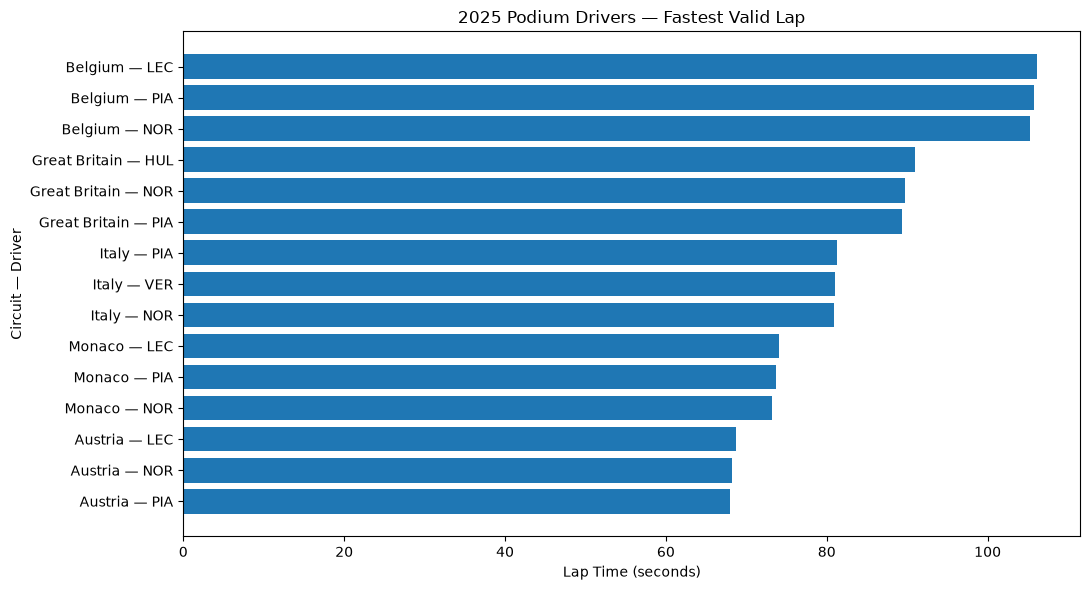

In [11]:
plot_summary = fastest_lap_summary.copy()

plot_summary["label"] = (
    plot_summary["circuit"]
    + " — "
    + plot_summary["driver"]
)

ordered = plot_summary.sort_values(
    "lap_time_seconds",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    ordered["label"],
    ordered["lap_time_seconds"]
)

ax.set_title(
    "2025 Podium Drivers — Fastest Valid Lap"
)

ax.set_xlabel(
    "Lap Time (seconds)"
)

ax.set_ylabel(
    "Circuit — Driver"
)

plt.tight_layout()
plt.show()

## 12. EDA — Speed Profile

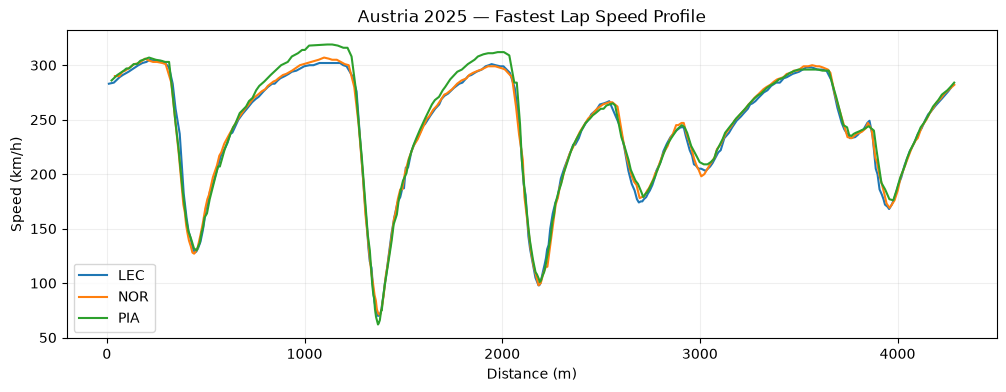

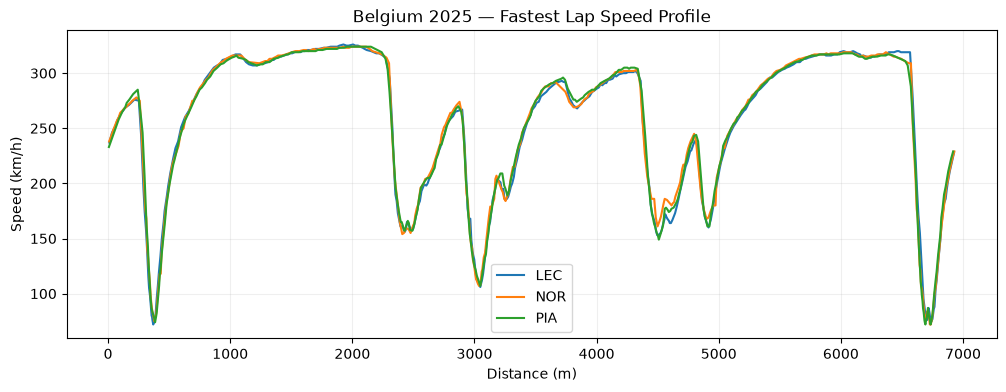

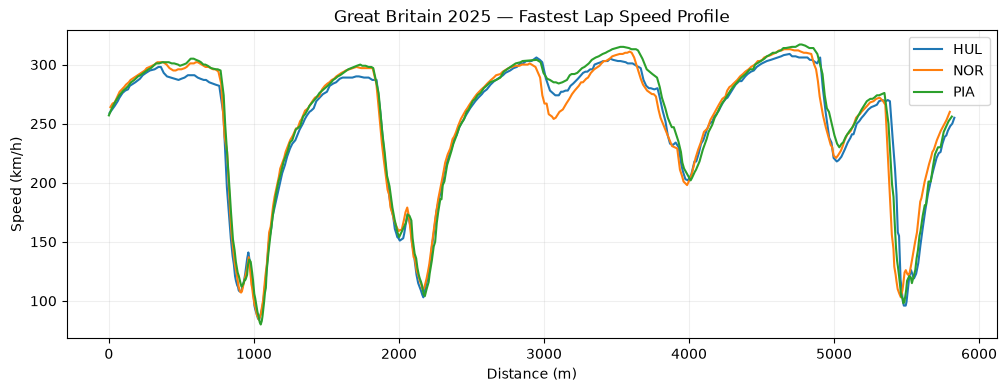

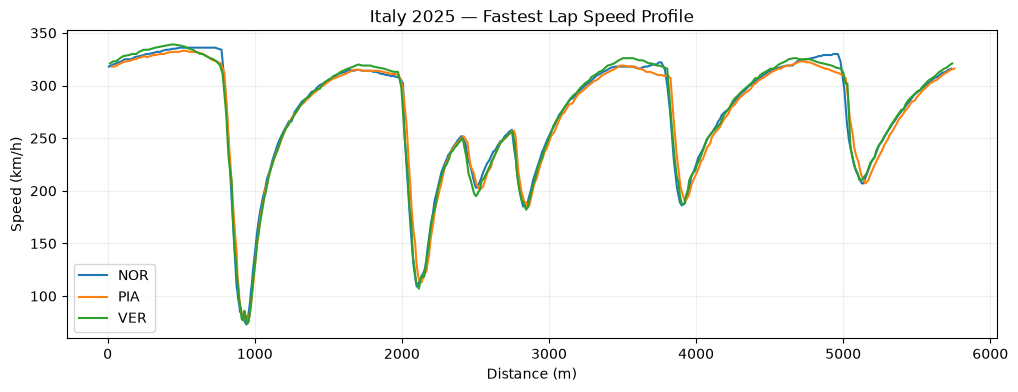

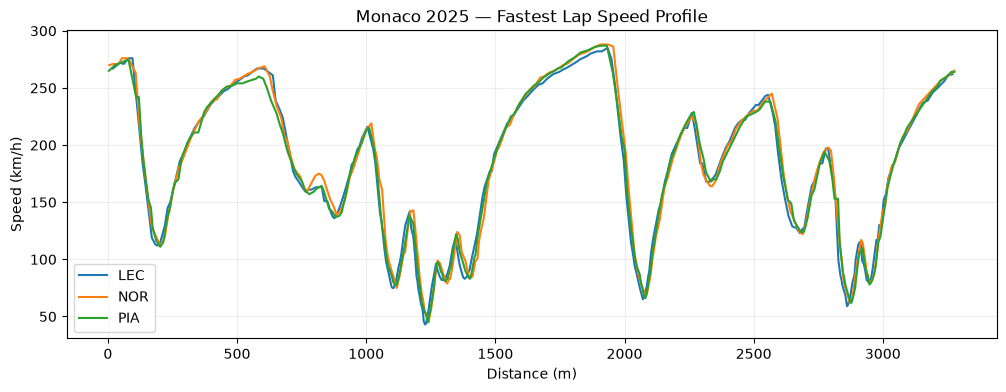

In [12]:
for circuit in (
    telemetry_master[
        "circuit"
    ].dropna().unique()
):
    subset = telemetry_master.loc[
        telemetry_master["circuit"].eq(
            circuit
        )
    ]

    fig, ax = plt.subplots(
        figsize=(12, 4)
    )

    for driver, driver_df in (
        subset.groupby("driver")
    ):
        driver_df = driver_df.sort_values(
            "distance_m"
        )

        ax.plot(
            driver_df["distance_m"],
            driver_df["speed_kmh"],
            label=driver
        )

    ax.set_title(
        f"{circuit} 2025 — "
        "Fastest Lap Speed Profile"
    )

    ax.set_xlabel("Distance (m)")
    ax.set_ylabel("Speed (km/h)")
    ax.grid(alpha=0.2)
    ax.legend()

    plt.show()

## 13. EDA — Throttle Profile

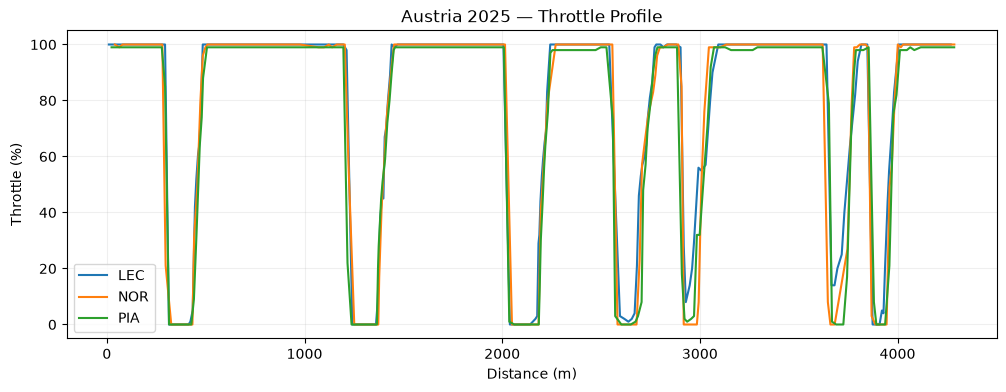

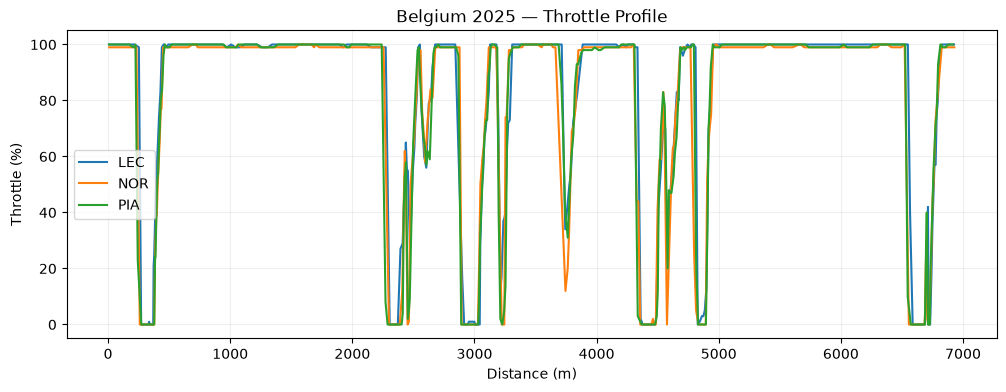

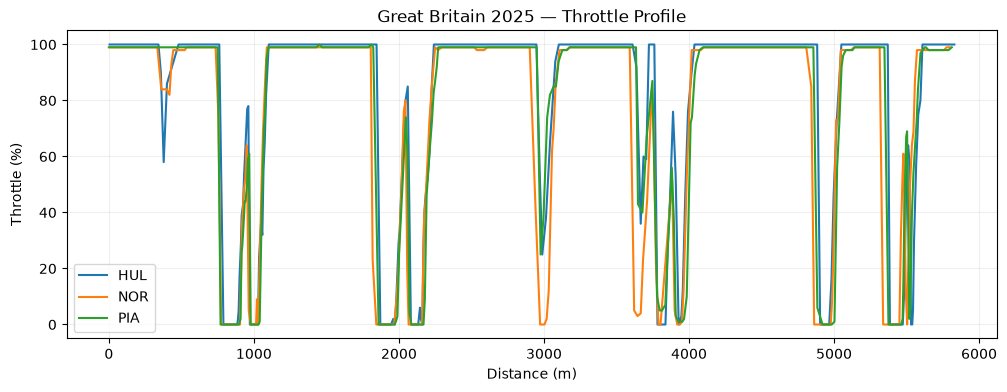

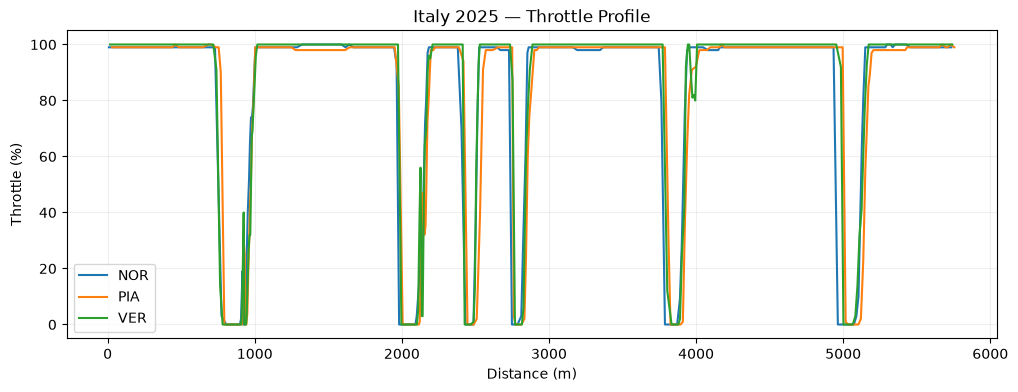

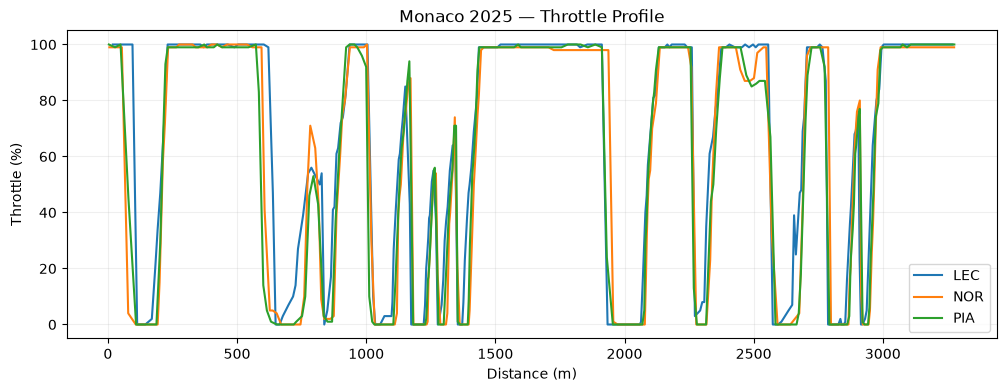

In [13]:
for circuit in (
    telemetry_master[
        "circuit"
    ].dropna().unique()
):
    subset = telemetry_master.loc[
        telemetry_master["circuit"].eq(
            circuit
        )
    ]

    fig, ax = plt.subplots(
        figsize=(12, 4)
    )

    for driver, driver_df in (
        subset.groupby("driver")
    ):
        driver_df = driver_df.sort_values(
            "distance_m"
        )

        ax.plot(
            driver_df["distance_m"],
            driver_df["throttle_pct"],
            label=driver
        )

    ax.set_title(
        f"{circuit} 2025 — "
        "Throttle Profile"
    )

    ax.set_xlabel("Distance (m)")
    ax.set_ylabel("Throttle (%)")
    ax.set_ylim(-5, 105)
    ax.grid(alpha=0.2)
    ax.legend()

    plt.show()

## 14. EDA — Circuit Speed Map

In [14]:
def plot_speed_map(df, title):
    required = {
        "x",
        "y",
        "speed_kmh",
        "distance_m"
    }

    if not required.issubset(
        df.columns
    ):
        print(
            "Missing columns:",
            required - set(df.columns)
        )
        return

    data = (
        df.dropna(
            subset=[
                "x",
                "y",
                "speed_kmh"
            ]
        )
        .sort_values("distance_m")
        .copy()
    )

    if len(data) < 3:
        return

    x = data["x"].to_numpy()
    y = data["y"].to_numpy()
    speed = (
        data["speed_kmh"]
        .to_numpy()
    )

    points = (
        np.array([x, y])
        .T
        .reshape(-1, 1, 2)
    )

    segments = np.concatenate(
        [
            points[:-1],
            points[1:]
        ],
        axis=1
    )

    norm = Normalize(
        vmin=np.nanmin(speed),
        vmax=np.nanmax(speed)
    )

    line = LineCollection(
        segments,
        cmap="turbo",
        norm=norm,
        linewidth=4
    )

    line.set_array(
        speed[:-1]
    )

    fig, ax = plt.subplots(
        figsize=(8, 6)
    )

    ax.add_collection(line)
    ax.autoscale()
    ax.set_aspect(
        "equal",
        adjustable="box"
    )
    ax.axis("off")
    ax.set_title(title)

    cbar = fig.colorbar(
        line,
        ax=ax
    )
    cbar.set_label(
        "Speed (km/h)"
    )

    plt.show()

for circuit in (
    telemetry_master[
        "circuit"
    ].dropna().unique()
):
    circuit_df = (
        telemetry_master.loc[
            telemetry_master[
                "circuit"
            ].eq(circuit)
        ]
    )

    best_finish_driver = (
        circuit_df
        .sort_values(
            "finish_position"
        )
        .iloc[0]["driver"]
    )

    plot_speed_map(
        circuit_df.loc[
            circuit_df["driver"].eq(
                best_finish_driver
            )
        ],
        (
            f"{circuit} 2025 — "
            f"{best_finish_driver} "
            "Fastest Lap Speed Map"
        )
    )

## 15. Export Clean CSV

In [15]:
telemetry_path = (
    OUTPUT_DIR
    / "fastf1_telemetry_2025_selected_circuits.csv"
)

summary_path = (
    OUTPUT_DIR
    / "fastf1_fastest_lap_summary_2025.csv"
)

error_path = (
    OUTPUT_DIR
    / "fastf1_extraction_errors_2025.csv"
)

telemetry_master.to_csv(
    telemetry_path,
    index=False
)

fastest_lap_summary.to_csv(
    summary_path,
    index=False
)

if not extraction_errors.empty:
    extraction_errors.to_csv(
        error_path,
        index=False
    )

print(
    "Saved:",
    telemetry_path,
    telemetry_master.shape
)

print(
    "Saved:",
    summary_path,
    fastest_lap_summary.shape
)

if not extraction_errors.empty:
    print(
        "Saved:",
        error_path,
        extraction_errors.shape
    )

Saved: /home/user/projects/avd-uts/outputs/fastf1_telemetry_2025_selected_circuits.csv (4630, 27)
Saved: /home/user/projects/avd-uts/outputs/fastf1_fastest_lap_summary_2025.csv (15, 18)


## 16. Final Validation

In [16]:
assert telemetry_master["season"].eq(
    SEASON
).all()

expected_circuits = set(
    TARGET_EVENTS.keys()
)

actual_circuits = set(
    telemetry_master[
        "circuit"
    ].dropna().unique()
)

print(
    "Expected circuits:",
    expected_circuits
)

print(
    "Actual circuits:",
    actual_circuits
)

validation = (
    telemetry_master.groupby(
        ["circuit", "driver"],
        dropna=False
    )
    .agg(
        samples=("distance_m", "size"),
        min_distance_m=(
            "distance_m",
            "min"
        ),
        max_distance_m=(
            "distance_m",
            "max"
        ),
        min_speed_kmh=(
            "speed_kmh",
            "min"
        ),
        max_speed_kmh=(
            "speed_kmh",
            "max"
        ),
        missing_speed=(
            "speed_kmh",
            lambda x: x.isna().sum()
        )
    )
    .reset_index()
)

display(validation)

if expected_circuits.issubset(
    actual_circuits
):
    print(
        "✅ Semua lima circuit tersedia."
    )
else:
    print(
        "⚠️ Missing circuits:",
        expected_circuits - actual_circuits
    )

print(
    "Outputs saved in:",
    OUTPUT_DIR
)

Expected circuits: {'Great Britain', 'Belgium', 'Monaco', 'Italy', 'Austria'}
Actual circuits: {'Great Britain', 'Belgium', 'Monaco', 'Italy', 'Austria'}


,circuit,driver,samples,min_distance_m,max_distance_m,min_speed_kmh,max_speed_kmh,missing_speed
0,Austria,LEC,260,10.376667,4269.066389,70.0,305.0,0
1,Austria,NOR,248,40.600000,4287.427500,71.0,307.0,0
2,Austria,PIA,243,23.912778,4286.687500,62.0,319.0,0
3,Belgium,LEC,384,10.533333,6926.423056,72.0,326.0,0
4,Belgium,NOR,390,8.925000,6928.799444,72.0,324.0,0
5,Belgium,PIA,386,6.795833,6918.946111,72.0,324.0,0
6,Great Britain,HUL,335,4.820278,5829.409444,84.0,309.0,0
7,Great Britain,NOR,336,10.633333,5798.212222,84.0,313.0,0
8,Great Britain,PIA,330,0.214167,5812.122778,80.0,317.0,0
9,Italy,NOR,295,8.303333,5735.339167,73.0,336.0,0


✅ Semua lima circuit tersedia.
Outputs saved in: /home/user/projects/avd-uts/outputs
